# Experiment Results Analysis

This notebook analyzes `experiment/experiment_results.csv` and produces paper-oriented figures plus diagnostic summaries:
- TRE / RE by projection mode
- testPoint distance effects
- angle effects (Angle M1-M2, M3-M1, M3-M2)
- Perspective vs Orthographic workflow-level sensitivity comparison (non-paired)
- input-volume comparison
- logging coverage for marker sorting, calibration, blackCenter auto-point flags, and timing fields

Cleaned outputs are written to `Analysis/Analysis/`, and figures are saved under `Analysis/Analysis/figures/`.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

from IPython.display import display


In [2]:
cwd = Path.cwd().resolve()
if (cwd / 'Biplane.py').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'Biplane.py').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

ANALYSIS_SRC_DIR = PROJECT_ROOT / 'Analysis'
ANALYSIS_DIR = ANALYSIS_SRC_DIR / 'Analysis'
FIG_DIR = ANALYSIS_DIR / 'figures'
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

default_csv_path = PROJECT_ROOT / 'experiment' / 'experiment_results.csv'
# Manually override this path if needed; otherwise prefer the repo raw CSV, then fall back to cleaned CSV.
manual_csv_path = default_csv_path if default_csv_path.exists() else None  # e.g. r'D:\\Data\\experiment_results.csv'

if manual_csv_path:
    csv_path = Path(manual_csv_path)
else:
    candidates = list(PROJECT_ROOT.rglob('experiment_results.csv'))
    if not candidates:
        candidates = list(PROJECT_ROOT.rglob('experiment_results_cleaned.csv'))
    if not candidates:
        raise FileNotFoundError('No experiment results CSV found. Please set manual_csv_path.')
    csv_path = max(candidates, key=lambda p: p.stat().st_mtime)

print(f'Project root: {PROJECT_ROOT}')
print(f'CSV path: {csv_path}')
print(f'Analysis output dir: {ANALYSIS_DIR}')
print(f'Figure output dir: {FIG_DIR}')


CSV path: d:\CodingHHW\Biplane\experiment\experiment_results.csv
Figure output dir: d:\CodingHHW\Biplane\Analysis\Analysis\figures


In [3]:
df_raw = pd.read_csv(csv_path, encoding='utf-8-sig')
df = df_raw.copy()

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

numeric_cols = [
    'shot2_angle_deg', 'shot3_angle_m3_m1_deg', 'shot3_angle_m3_m2_deg',
    'tre_value_mm', 'reprojection_error_px', 'ray_gap_mm',
    'markers_sorted', 'perspective_calibration_ready', 'orthographic_calibration_ready',
    'shot1_available', 'shot2_available', 'shot3_available',
    'testpoint_x', 'testpoint_y', 'testpoint_z',
    'testpoint_marker_distance_t1_mm', 'testpoint_marker_distance_t2_mm',
    'testpoint_marker_distance_t3_mm', 'testpoint_marker_distance_mean_mm',
    'camera_view_angle_deg', 'view_orthographic_enabled',
    'red_uses_blackcenter_auto_point', 'green_uses_blackcenter_auto_point',
    'uses_blackcenter_auto_point_any',
]
numeric_prefixes = (
    'marker_sort_view',
    'perspective_calibration_view',
    'orthographic_calibration_view',
    'timing_',
)
for col in df.columns:
    if col in numeric_cols or col.startswith(numeric_prefixes):
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'projection_mode' in df.columns:
    mode = df['projection_mode'].astype(str).str.strip().str.lower()
    df['projection_mode'] = mode.map({
        'perspective': 'Perspective',
        'orthographic': 'Orthographic',
    }).fillna(mode.str.title())
else:
    df['projection_mode'] = 'Unknown'

if 'input_volume' not in df.columns:
    df['input_volume'] = 'Unknown'
df['input_volume'] = df['input_volume'].fillna('Unknown').astype(str)

if 'testpoint_marker_distance_mean_mm' not in df.columns:
    dist_cols = [c for c in [
        'testpoint_marker_distance_t1_mm',
        'testpoint_marker_distance_t2_mm',
        'testpoint_marker_distance_t3_mm',
    ] if c in df.columns]
    if dist_cols:
        df['testpoint_marker_distance_mean_mm'] = df[dist_cols].mean(axis=1, skipna=True)

dist_col = 'testpoint_marker_distance_mean_mm'
if dist_col in df.columns and df[dist_col].notna().sum() >= 9:
    df['distance_group'] = pd.qcut(df[dist_col], q=3, labels=['Near', 'Mid', 'Far'], duplicates='drop')
elif dist_col in df.columns and df[dist_col].notna().sum() >= 3:
    df['distance_group'] = pd.cut(df[dist_col], bins=3, labels=['Near', 'Mid', 'Far'])
else:
    df['distance_group'] = np.nan

quality_mask = pd.Series(True, index=df.index)
for col in ['markers_sorted', 'shot1_available', 'shot2_available', 'shot3_available']:
    if col in df.columns:
        quality_mask &= df[col].fillna(0).astype(float) > 0

df_q = df.loc[quality_mask].copy()

print(f'Raw rows: {len(df_raw)}')
print(f'Quality rows: {len(df_q)}')
print(f'Columns: {len(df_q.columns)}')


Raw rows: 284
Quality rows: 284
Columns: 38


In [4]:
summary = pd.DataFrame({
    'n_rows': [len(df_q)],
    'n_modes': [df_q['projection_mode'].nunique(dropna=True)],
    'n_volumes': [df_q['input_volume'].nunique(dropna=True)],
    'tre_mean_mm': [df_q['tre_value_mm'].mean() if 'tre_value_mm' in df_q else np.nan],
    'tre_std_mm': [df_q['tre_value_mm'].std() if 'tre_value_mm' in df_q else np.nan],
    're_mean_px': [df_q['reprojection_error_px'].mean() if 'reprojection_error_px' in df_q else np.nan],
    're_std_px': [df_q['reprojection_error_px'].std() if 'reprojection_error_px' in df_q else np.nan],
})
display(summary.round(4))

print('Count by projection mode:')
display(df_q['projection_mode'].value_counts(dropna=False).to_frame('count'))

print('Count by input volume (top 10):')
display(df_q['input_volume'].value_counts(dropna=False).head(10).to_frame('count'))

display(df_q.head())


,n_rows,n_modes,n_volumes,tre_mean_mm,tre_std_mm,re_mean_px,re_std_px
0,284,2,2,0.1752,0.1303,0.1867,0.1831


Count by projection mode:


,count
projection_mode,
Orthographic,143
Perspective,141


Count by input volume (top 10):


,count
input_volume,
CTChest,145
Panoramix-cropped,139


,timestamp,csv_output_path,input_volume,projection_mode,projection_mode_status,markers_sorted,perspective_calibration_ready,orthographic_calibration_ready,shot1_available,shot2_available,...,testpoint_y,testpoint_z,testpoint_marker_distance_t1_mm,testpoint_marker_distance_t2_mm,testpoint_marker_distance_t3_mm,testpoint_marker_distance_mean_mm,debug_visualization,debug_plane_scale,debug_ray_scale,distance_group
0,2026-03-01 17:40:20+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,90.177864,-129.802170,79.133727,92.570916,83.167227,84.957290,0,6.0,10.0,Near
1,2026-03-01 17:46:38+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,90.849548,-183.689804,41.994902,61.555962,38.666548,47.405804,0,6.0,10.0,Near
2,2026-03-01 17:49:52+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,58.072670,-39.549397,173.679602,183.093313,178.461762,178.411559,0,6.0,10.0,Mid
3,2026-03-01 17:51:14+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,69.253166,-167.190079,114.213280,134.325077,112.703530,120.413962,0,6.0,10.0,Near
4,2026-03-01 17:52:57+08:00,C:\Users\80758\AppData\Local\Temp\Slicer\Bipla...,CTChest,Perspective,Current mode: Perspective,1,1,0,1,1,...,54.932411,-93.910095,153.413872,169.995424,155.643575,159.684290,0,6.0,10.0,Mid


In [ ]:
# Diagnostic logging overview
diagnostic_groups = {
    'Marker sort RMS': [c for c in df_q.columns if c.startswith('marker_sort_view') and c.endswith('_rms_px')],
    'Perspective calibration RMS': [c for c in df_q.columns if c.startswith('perspective_calibration_view') and c.endswith('_reproj_rms_px')],
    'Orthographic calibration RMS': [c for c in df_q.columns if c.startswith('orthographic_calibration_view') and c.endswith('_reproj_rms_px')],
    'Timing fields': [c for c in df_q.columns if c.startswith('timing_')],
    'blackCenter usage flags': [
        c for c in [
            'red_uses_blackcenter_auto_point',
            'green_uses_blackcenter_auto_point',
            'uses_blackcenter_auto_point_any',
        ] if c in df_q.columns
    ],
}

diagnostic_coverage_rows = []
for group_name, cols in diagnostic_groups.items():
    if not cols:
        continue
    sub = df_q[cols]
    diagnostic_coverage_rows.append({
        'group': group_name,
        'n_columns': len(cols),
        'row_complete_rate': sub.notna().all(axis=1).mean(),
        'cell_non_null_rate': sub.notna().mean().mean(),
    })

if diagnostic_coverage_rows:
    diagnostic_coverage = pd.DataFrame(diagnostic_coverage_rows)
    display(diagnostic_coverage.round(4))
else:
    print('No diagnostic logging columns found in the selected CSV.')

diagnostic_numeric_cols = [
    c for c in df_q.columns
    if (c.endswith('_rms_px') or c == 'camera_view_angle_deg') and pd.api.types.is_numeric_dtype(df_q[c])
]
if diagnostic_numeric_cols:
    print('Diagnostic metric summary:')
    display(df_q[diagnostic_numeric_cols].describe().T[['count', 'mean', '50%', 'max']].round(4))

timing_cols = [c for c in df_q.columns if c.startswith('timing_') and pd.api.types.is_numeric_dtype(df_q[c])]
if timing_cols:
    print('Timing summary (ms):')
    display(df_q[timing_cols].describe().T[['count', 'mean', '50%', 'max']].round(3))

if 'uses_blackcenter_auto_point_any' in df_q.columns:
    print('blackCenter auto-point usage:')
    display(df_q['uses_blackcenter_auto_point_any'].value_counts(dropna=False).rename_axis('uses_blackcenter_auto_point_any').to_frame('count'))


In [5]:
def save_fig(fig, filename: str):
    out = FIG_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved: {out}')

def identity_line(ax, values):
    v = np.asarray(values, dtype=float)
    if len(v) == 0:
        return
    lo, hi = np.nanmin(v), np.nanmax(v)
    if not np.isfinite(lo) or not np.isfinite(hi):
        return
    ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1)


Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\01_error_distribution_by_mode.png


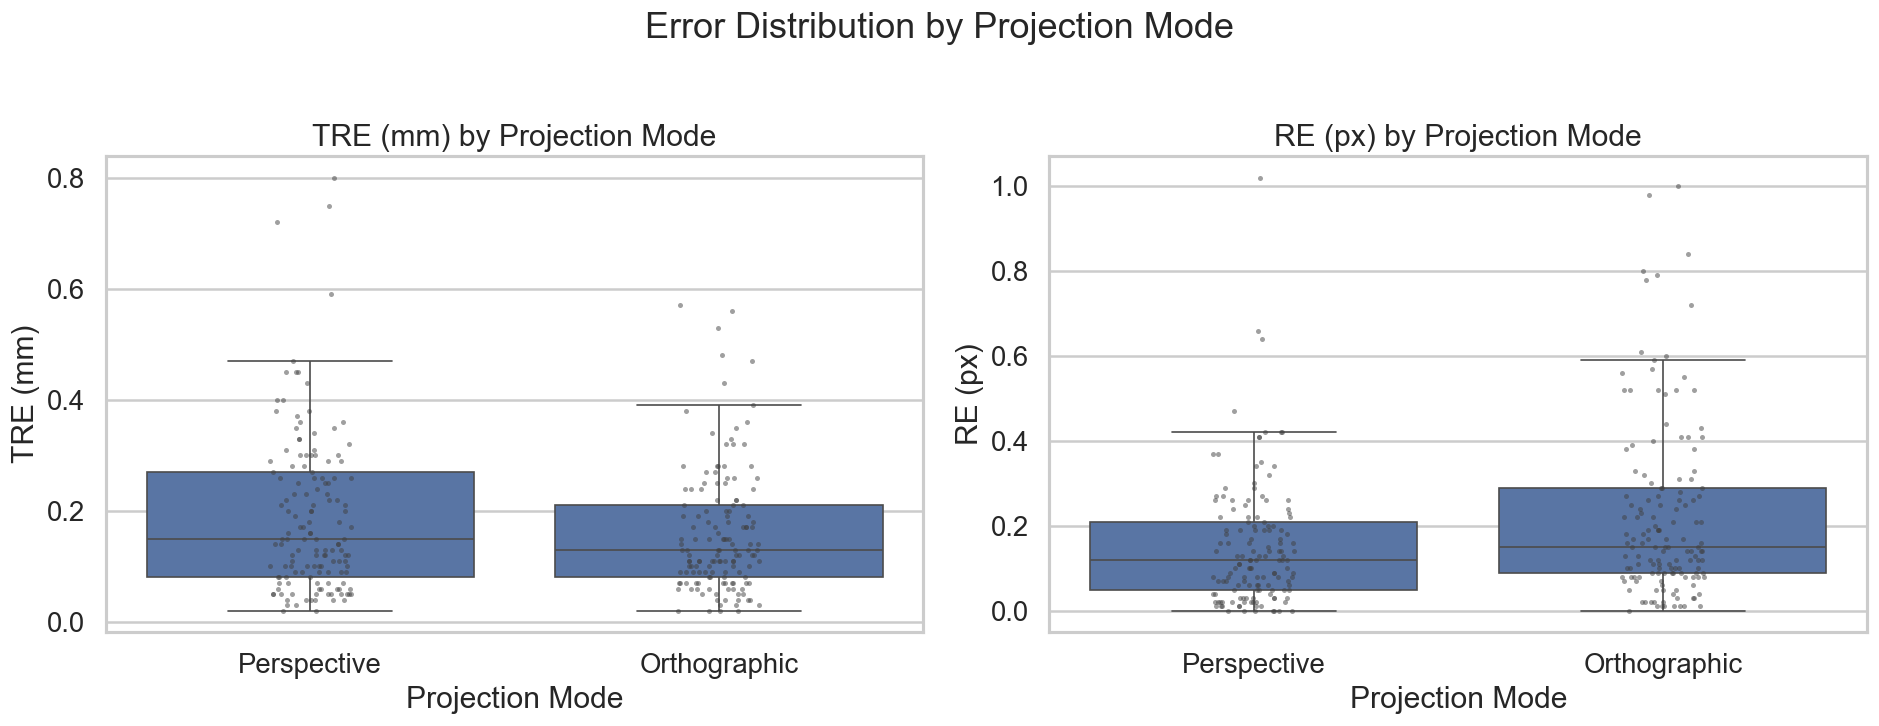

In [6]:
# 图1：TRE/RE 在不同模式下的分布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_specs = [
    ('tre_value_mm', 'TRE (mm)'),
    ('reprojection_error_px', 'RE (px)'),
]

for ax, (col, ylabel) in zip(axes, plot_specs):
    if col not in df_q.columns or df_q[col].notna().sum() == 0:
        ax.text(0.5, 0.5, f'No data: {col}', ha='center', va='center')
        ax.set_axis_off()
        continue
    sns.boxplot(data=df_q, x='projection_mode', y=col, ax=ax, fliersize=0)
    sns.stripplot(data=df_q, x='projection_mode', y=col, ax=ax, color='0.25', alpha=0.5, size=3)
    ax.set_xlabel('Projection Mode')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Projection Mode')

fig.suptitle('Error Distribution by Projection Mode', y=1.02)
fig.tight_layout()
save_fig(fig, '01_error_distribution_by_mode.png')
plt.show()


Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\02_distance_effect_scatter.png


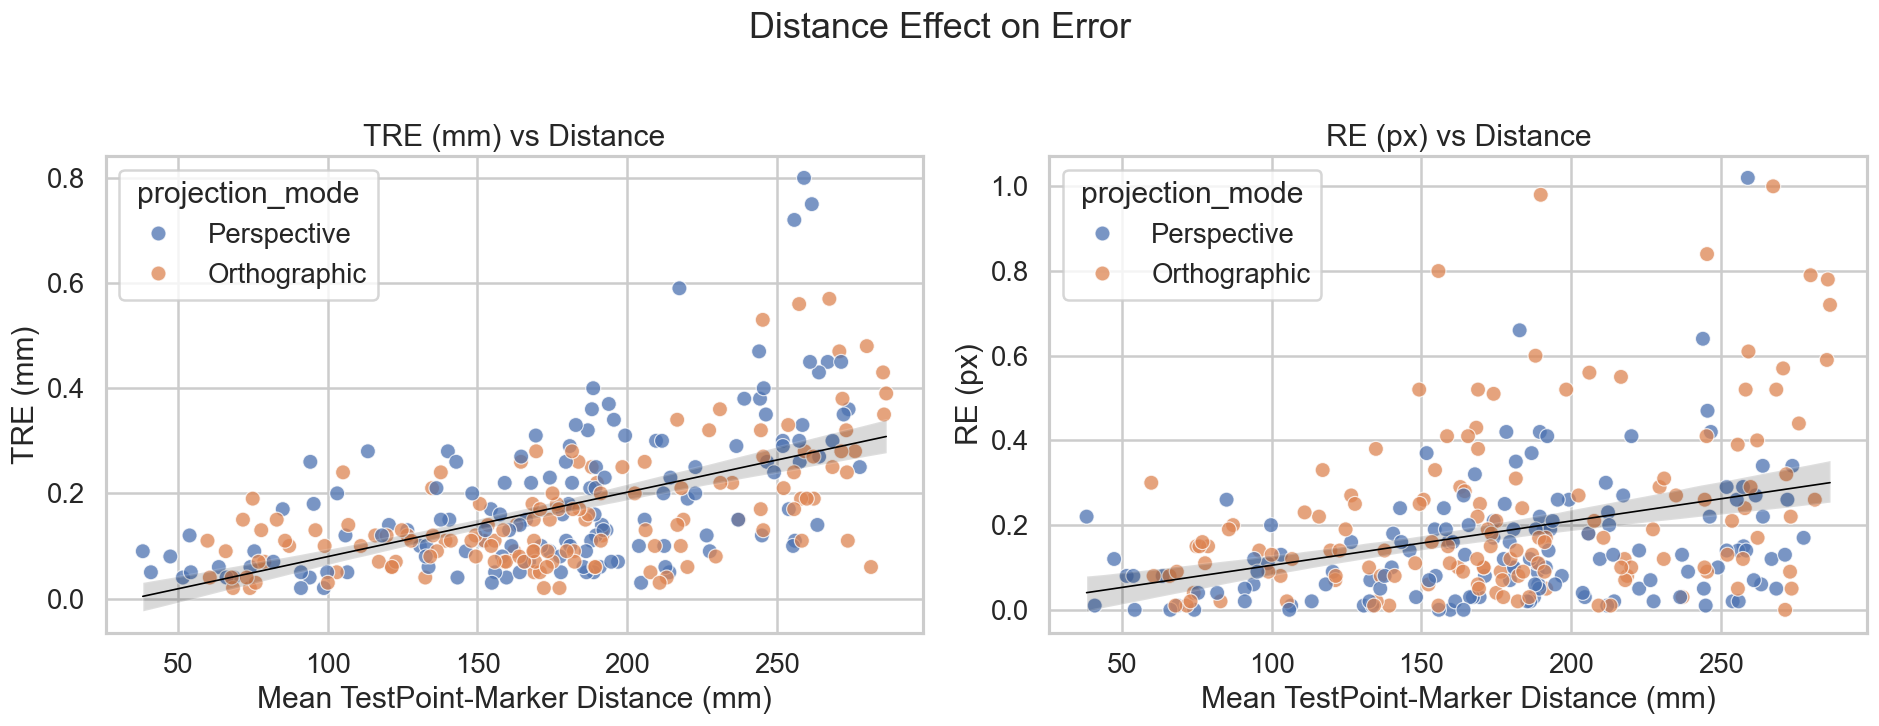

Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\03_distance_group_boxplots.png


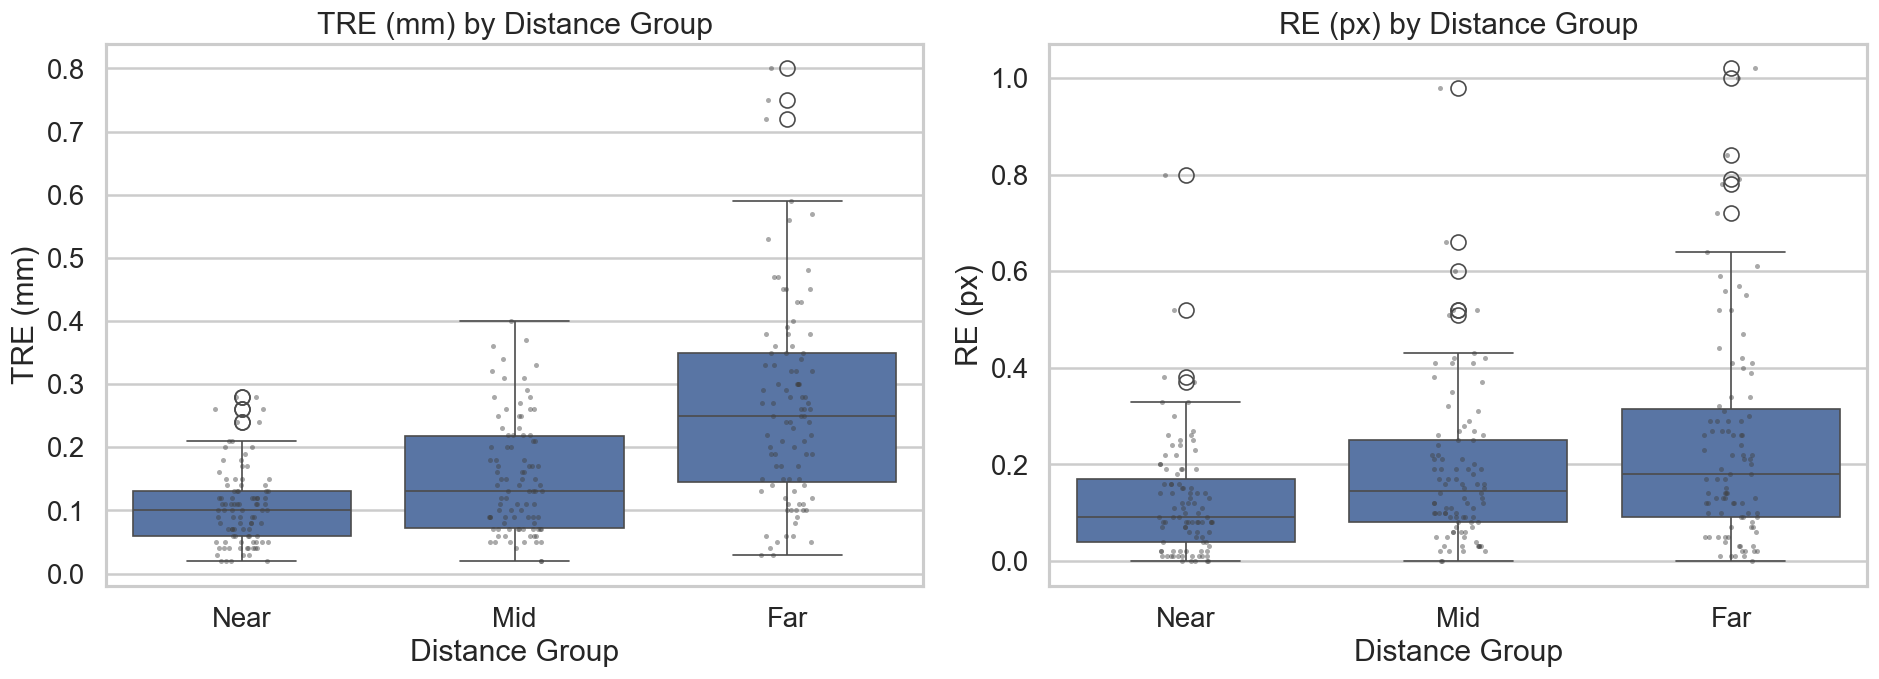

In [7]:
# 图2：距离效应（距离 vs TRE/RE）
dist_col = 'testpoint_marker_distance_mean_mm'
if dist_col in df_q.columns and df_q[dist_col].notna().sum() >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, (ycol, ylabel) in zip(axes, [('tre_value_mm', 'TRE (mm)'), ('reprojection_error_px', 'RE (px)')]):
        sub = df_q[[dist_col, ycol, 'projection_mode']].dropna()
        if len(sub) < 3:
            ax.text(0.5, 0.5, f'Insufficient data: {ycol}', ha='center', va='center')
            ax.set_axis_off()
            continue
        sns.scatterplot(data=sub, x=dist_col, y=ycol, hue='projection_mode', alpha=0.75, ax=ax)
        sns.regplot(data=sub, x=dist_col, y=ycol, scatter=False, color='black', line_kws={'lw': 1}, ax=ax)
        ax.set_xlabel('Mean TestPoint-Marker Distance (mm)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs Distance')

    fig.suptitle('Distance Effect on Error', y=1.02)
    fig.tight_layout()
    save_fig(fig, '02_distance_effect_scatter.png')
    plt.show()

    if 'distance_group' in df_q.columns and df_q['distance_group'].notna().sum() > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, (ycol, ylabel) in zip(axes, [('tre_value_mm', 'TRE (mm)'), ('reprojection_error_px', 'RE (px)')]):
            sub = df_q[['distance_group', ycol]].dropna()
            if len(sub) < 3:
                ax.text(0.5, 0.5, f'Insufficient data: {ycol}', ha='center', va='center')
                ax.set_axis_off()
                continue
            sns.boxplot(data=sub, x='distance_group', y=ycol, ax=ax, order=['Near', 'Mid', 'Far'])
            sns.stripplot(data=sub, x='distance_group', y=ycol, ax=ax, color='0.25', alpha=0.45, size=3, order=['Near', 'Mid', 'Far'])
            ax.set_xlabel('Distance Group')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{ylabel} by Distance Group')

        fig.tight_layout()
        save_fig(fig, '03_distance_group_boxplots.png')
        plt.show()
else:
    print('未检测到可用的 testpoint_marker_distance_mean_mm 数据，跳过距离效应图。')


Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\04_angle_effects.png


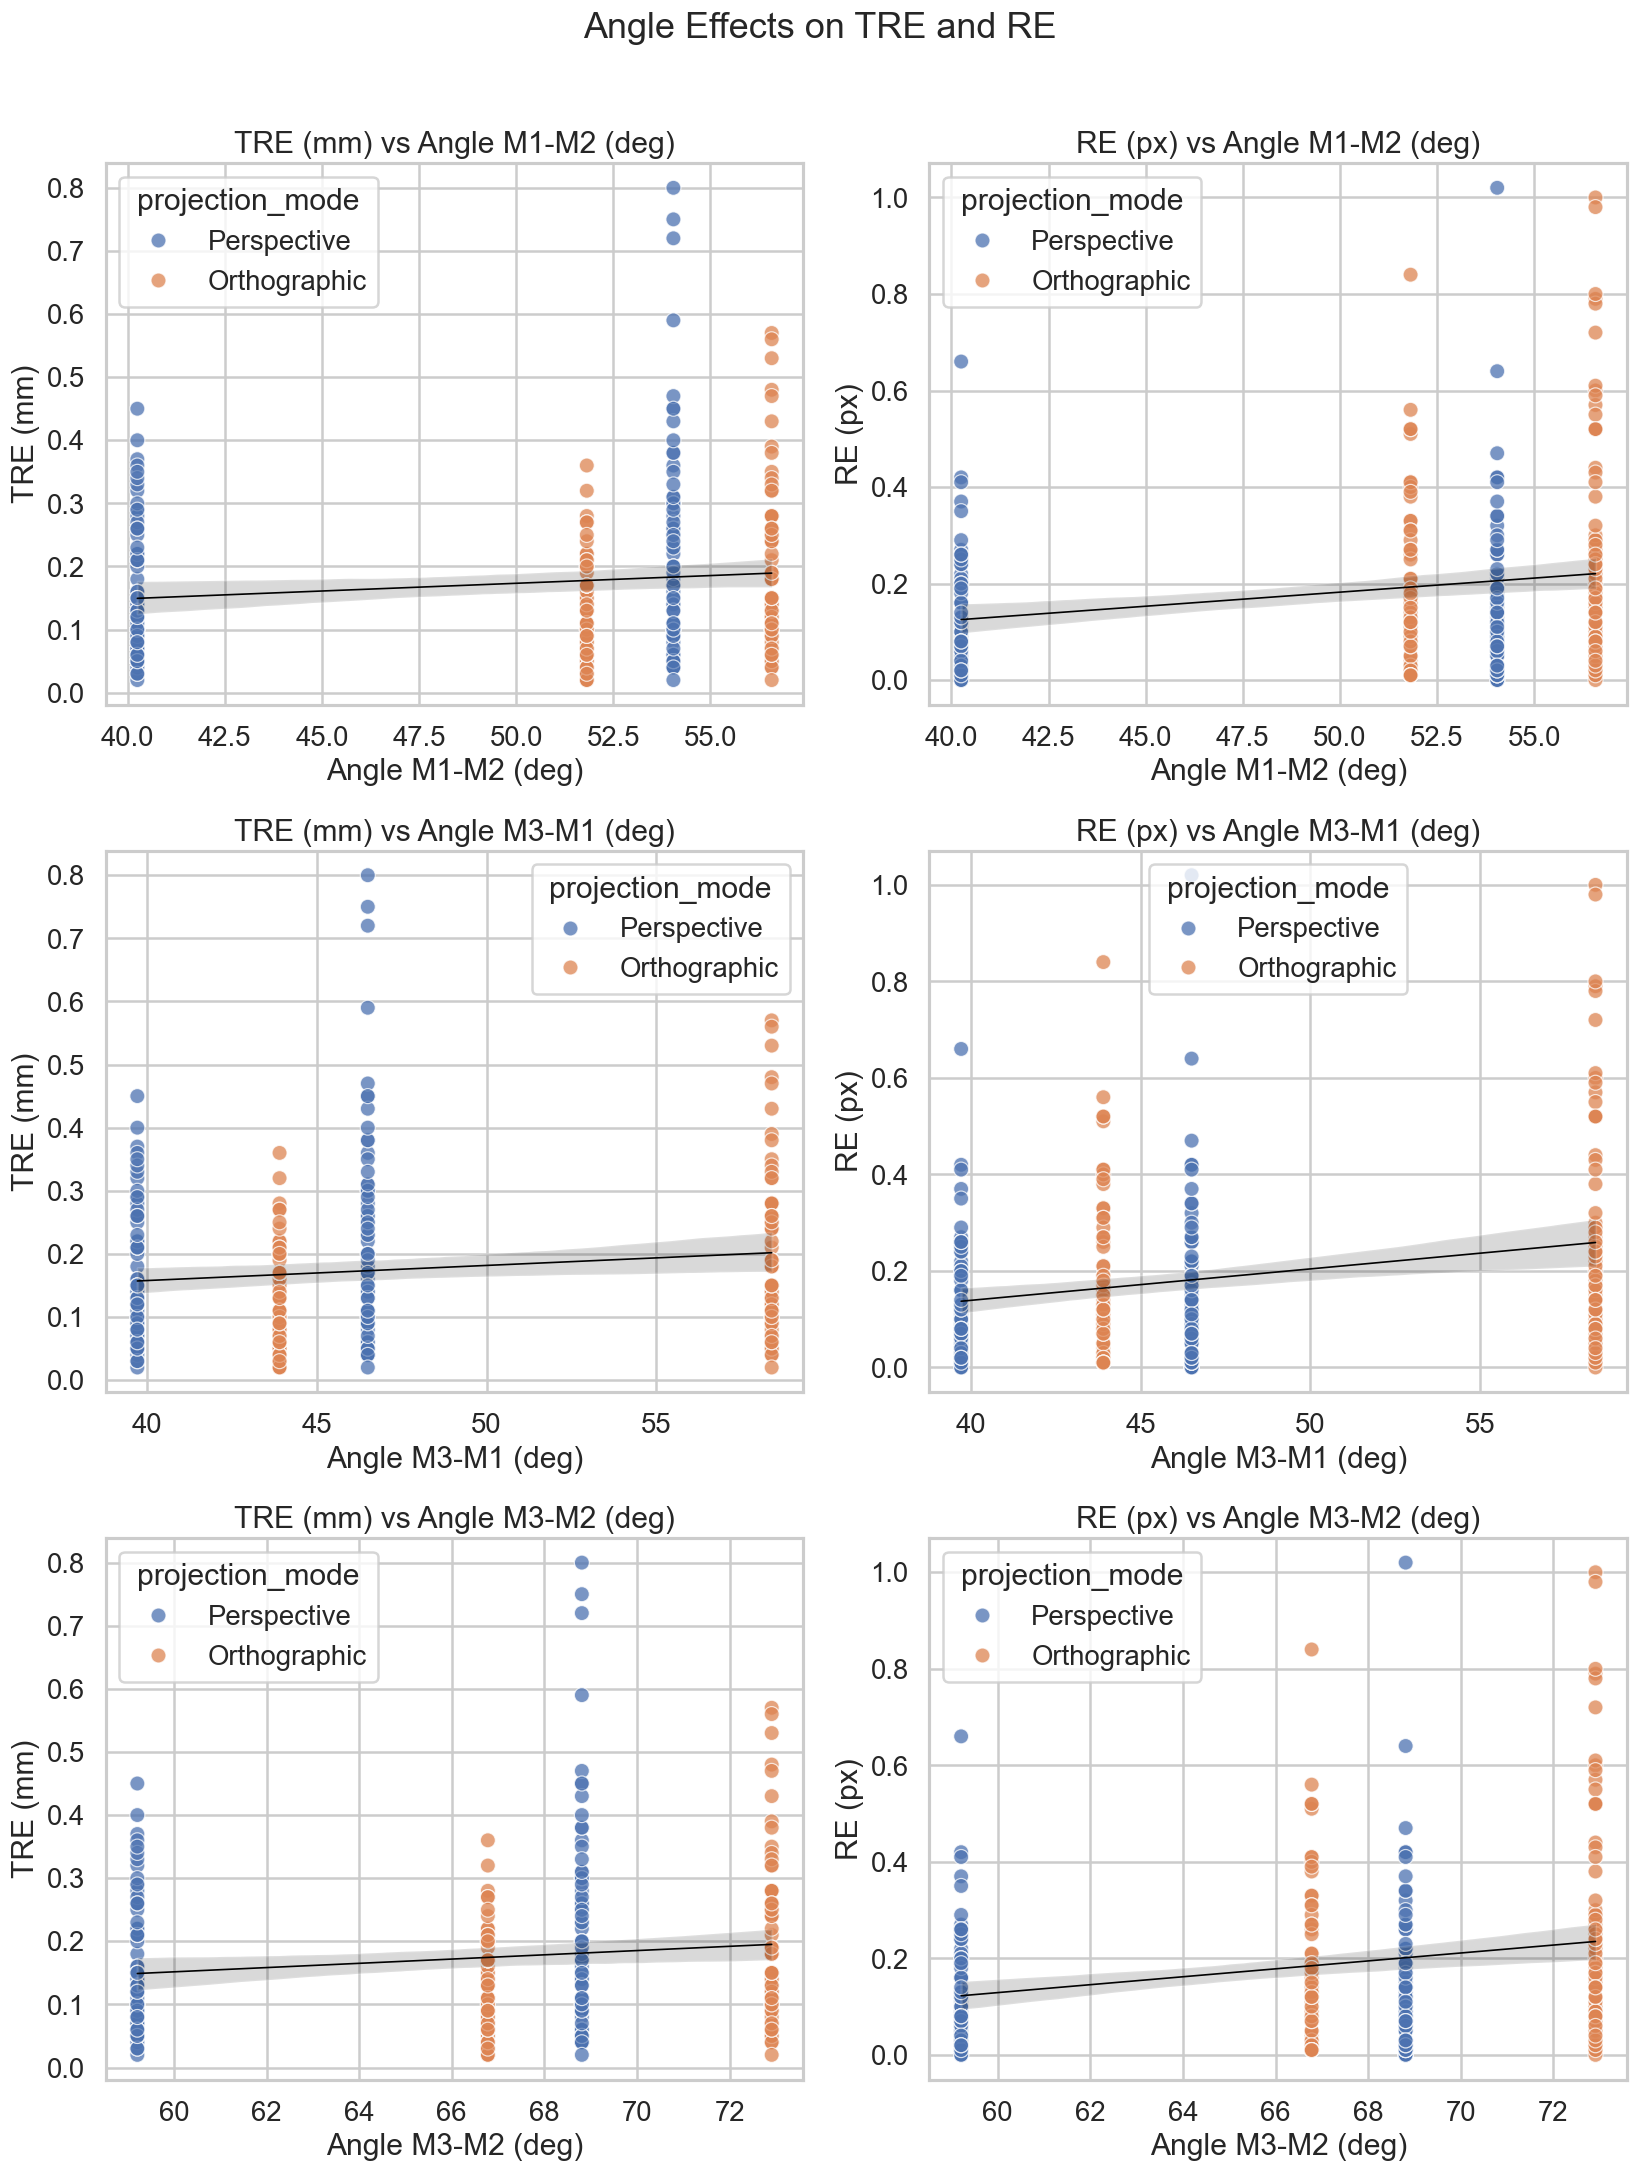

In [9]:
# 图3：角度效应（3个角度 × 2个误差）
angle_cols = [
    ('shot2_angle_deg', 'Angle M1-M2 (deg)'),
    ('shot3_angle_m3_m1_deg', 'Angle M3-M1 (deg)'),
    ('shot3_angle_m3_m2_deg', 'Angle M3-M2 (deg)'),
]
metric_cols = [('tre_value_mm', 'TRE (mm)'), ('reprojection_error_px', 'RE (px)')]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
for i, (xcol, xlabel) in enumerate(angle_cols):
    for j, (ycol, ylabel) in enumerate(metric_cols):
        ax = axes[i, j]
        if xcol not in df_q.columns or ycol not in df_q.columns:
            ax.text(0.5, 0.5, f'Missing: {xcol} or {ycol}', ha='center', va='center')
            ax.set_axis_off()
            continue
        sub = df_q[[xcol, ycol, 'projection_mode']].dropna()
        if len(sub) < 3:
            ax.text(0.5, 0.5, f'Insufficient data: {xcol}', ha='center', va='center')
            ax.set_axis_off()
            continue
        sns.scatterplot(data=sub, x=xcol, y=ycol, hue='projection_mode', alpha=0.75, ax=ax)
        sns.regplot(data=sub, x=xcol, y=ycol, scatter=False, color='black', line_kws={'lw': 1}, ax=ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} vs {xlabel}')

fig.suptitle('Angle Effects on TRE and RE', y=1.01)
fig.tight_layout()
save_fig(fig, '04_angle_effects.png')
plt.show()


In [ ]:
# Figure 4: Perspective vs Orthographic workflow sensitivity analysis
import importlib.util

projection_equivalence_margins = {
    'tre_value_mm': None,  # set a numeric margin such as 0.05 if you want an equivalence check
    'reprojection_error_px': None,  # set a numeric margin such as 0.05 if you want an equivalence check
}

helper_candidates = [
    PROJECT_ROOT / 'projection_workflow_analysis.py',
    PROJECT_ROOT / 'Analysis' / 'projection_workflow_analysis.py',
]
helper_path = next((path for path in helper_candidates if path.exists()), None)
if helper_path is None:
    raise FileNotFoundError('projection_workflow_analysis.py not found.')

spec = importlib.util.spec_from_file_location('projection_workflow_analysis', helper_path)
projection_workflow_analysis = importlib.util.module_from_spec(spec)
spec.loader.exec_module(projection_workflow_analysis)

projection_mode_results = projection_workflow_analysis.run_projection_workflow_analysis(
    df_q=df_q,
    save_fig=save_fig,
    display_fn=display,
    scipy_available=SCIPY_AVAILABLE,
    stats_module=stats if SCIPY_AVAILABLE else None,
    bootstrap_iterations=4000,
    equivalence_margins=projection_equivalence_margins,
)

projection_mode_matching = projection_mode_results['matching_diagnostics']
projection_mode_summary = projection_mode_results['mode_summary']
projection_mode_comparison = projection_mode_results['comparison_summary']


Saved: d:\CodingHHW\Biplane\Analysis\Analysis\figures\07_volume_comparison.png


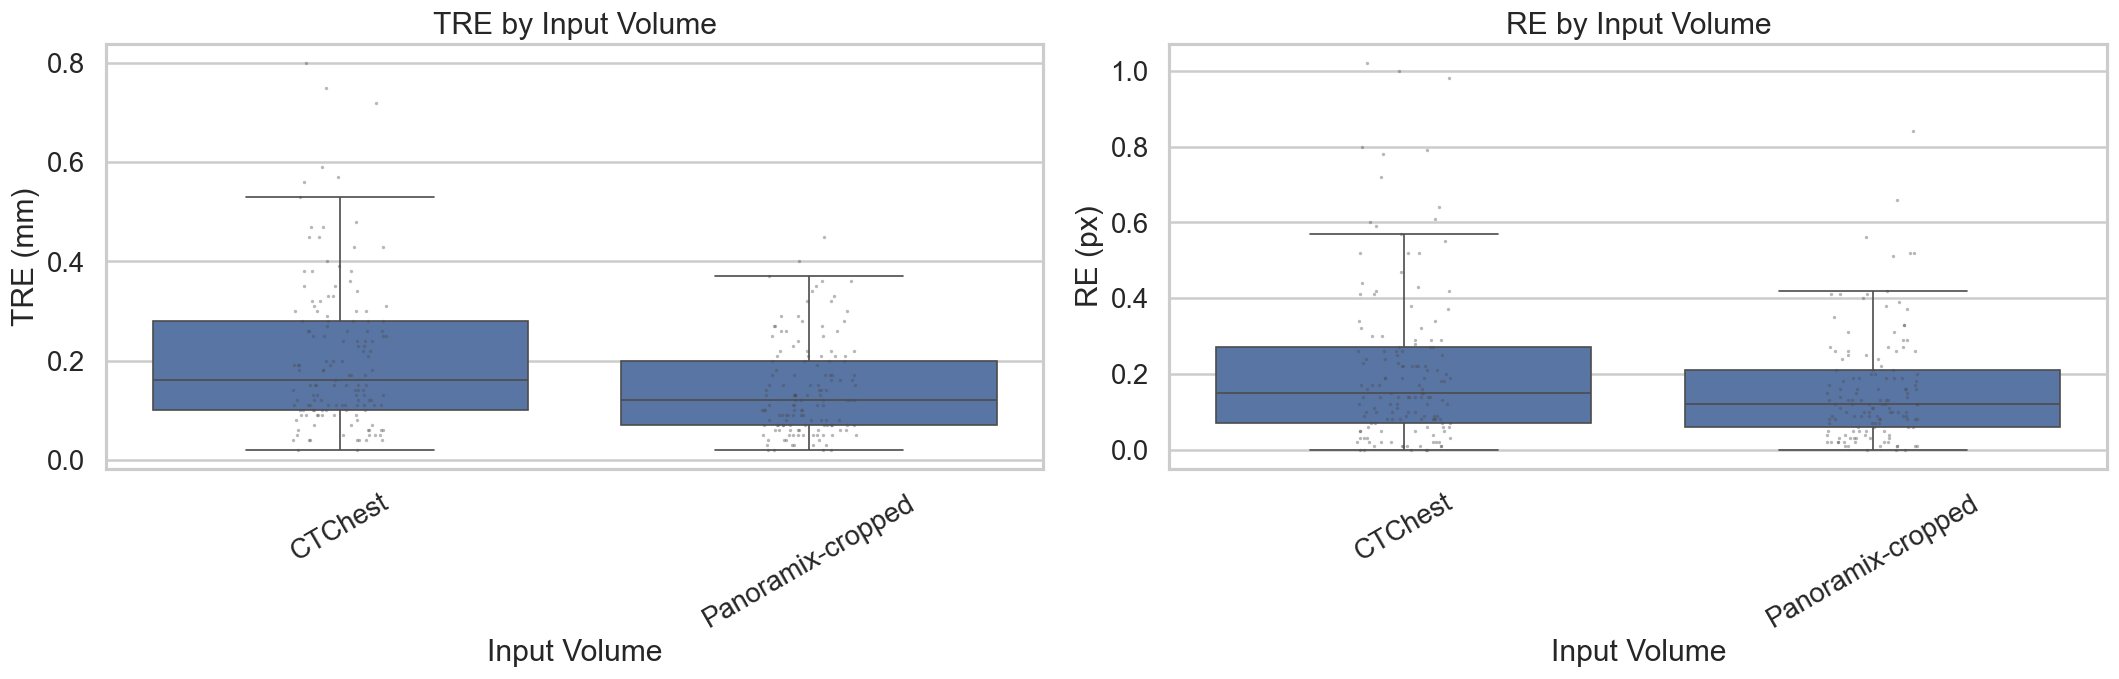

In [11]:
# 图5：不同体数据对比（仅显示样本量最多的前8个）
if 'input_volume' in df_q.columns and df_q['input_volume'].nunique() > 1:
    top_volumes = df_q['input_volume'].value_counts().head(8).index.tolist()
    sub = df_q[df_q['input_volume'].isin(top_volumes)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.boxplot(data=sub, x='input_volume', y='tre_value_mm', ax=axes[0], fliersize=0)
    sns.stripplot(data=sub, x='input_volume', y='tre_value_mm', ax=axes[0], color='0.3', alpha=0.4, size=2)
    axes[0].set_title('TRE by Input Volume')
    axes[0].set_xlabel('Input Volume')
    axes[0].set_ylabel('TRE (mm)')
    axes[0].tick_params(axis='x', rotation=30)

    sns.boxplot(data=sub, x='input_volume', y='reprojection_error_px', ax=axes[1], fliersize=0)
    sns.stripplot(data=sub, x='input_volume', y='reprojection_error_px', ax=axes[1], color='0.3', alpha=0.4, size=2)
    axes[1].set_title('RE by Input Volume')
    axes[1].set_xlabel('Input Volume')
    axes[1].set_ylabel('RE (px)')
    axes[1].tick_params(axis='x', rotation=30)

    fig.tight_layout()
    save_fig(fig, '07_volume_comparison.png')
    plt.show()
else:
    print('只有一个 input_volume 或缺少该列，跳过体数据对比图。')


In [12]:
# Export cleaned data and summary tables
clean_csv = ANALYSIS_DIR / 'experiment_results_cleaned.csv'
summary_csv = ANALYSIS_DIR / 'analysis_summary.csv'

df_q.to_csv(clean_csv, index=False, encoding='utf-8-sig')
summary.round(6).to_csv(summary_csv, index=False, encoding='utf-8-sig')

print(f'Cleaned data saved: {clean_csv}')
print(f'Summary saved: {summary_csv}')
print('Cleaned CSV keeps the diagnostic logging fields for downstream analysis.')
print(f'Figures dir: {FIG_DIR}')


Cleaned data saved: d:\CodingHHW\Biplane\Analysis\Analysis\experiment_results_cleaned.csv
Summary saved: d:\CodingHHW\Biplane\Analysis\Analysis\analysis_summary.csv
Figures dir: d:\CodingHHW\Biplane\Analysis\Analysis\figures
